<a href="https://colab.research.google.com/github/isisgualdi/isisgualdi/blob/main/students.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Isis Gualdi Vasconcelos da Silva (2023.1)

Escolhi o dataset "Student Performance" do UC Irvine Machine Learning Repository. Estes dados foram coletados por meio de relatórios escolares e questionários e abordam o desempenho dos alunos no ensino secundário de duas escolas portuguesas. Os atributos de dados incluem notas dos alunos, características demográficas, sociais e relacionadas à escola. São fornecidos dois conjuntos de dados relativos ao desempenho em duas disciplinas distintas: Matemática e Língua Portuguesa. **Para esta análise, escolhi o conjunto de dados sobre a disciplina de Matemática.**


Fonte: https://archive.ics.uci.edu/dataset/320/student+performance


---



# Dicionário de dados
- school - escola do aluno (binário: 'GP' - Gabriel Pereira ou 'MS' - Mousinho da Silveira)
- sex - sexo do aluno (binário: 'F' - feminino ou 'M' - masculino)
- age - idade do aluno (numérico: de 15 a 22)
- address - tipo de endereço residencial do aluno (binário: 'U' - urbano ou 'R' - rural)
- famsize - tamanho da família (binário: 'LE3' - menor ou igual a 3 ou 'GT3' - maior que 3)
- Pstatus - situação de coabitação dos pais (binário: 'T' - morando juntos ou 'A' - separados)
- Medu - escolaridade da mãe (numérico: 0 - nenhuma, 1 - ensino fundamental (4ª série), 2 - 5ª a 9ª série, 3 - ensino médio ou 4 - ensino superior)
- Fedu - escolaridade do pai (numérico: 0 - nenhuma, 1 - ensino fundamental (4ª série), 2 - 5ª a 9ª série, 3 - ensino médio ou 4 - ensino superior)
- Mjob - trabalho da mãe (nominal: 'professor', 'saúde' relacionado a cuidados, 'serviços' civis (por exemplo, administrativo ou policial), 'at_home' ou 'outros')
- Fjob - trabalho do pai (nominal: 'professor', 'saúde' relacionado a cuidados, 'serviços' civis (por exemplo, administrativo ou policial), 'at_home' ou 'outros')
- reason - razão para escolher esta escola (nominal: perto de 'casa', 'reputação' da escola, preferência de 'curso' ou 'outro')
- guardian - tutor do aluno (nominal: 'mãe', 'pai' ou 'outro')
- traveltime - tempo de viagem de casa para a escola (numérico: 1 - <15 min., 2 - 15 a 30 min., 3 - 30 min. a 1 hora, ou 4 - >1 hora)
- studytime - tempo de estudo semanal (numérico: 1 - <2 horas, 2 - 2 a 5 horas, 3 - 5 a 10 horas ou 4 - >10 horas)
- failures - número de reprovações anteriores (numérico: n se 1<=n<3, senão 4)
- schoolsup - apoio educacional extra (binário: sim ou não)
- famsup - apoio educacional familiar (binário: sim ou não)
- paid - alas extras pagas dentro da disciplina do curso (Matemática ou Português) (binário: sim ou não)
- activities - atividades extracurriculares (binário: sim ou não)
- nursery - frequentou creche (binário: sim ou não)
- higher - quer cursar ensino superior (binário: sim ou não)
- internet - Acesso à internet em casa (binário: sim ou não)
- romantic - com relacionamento romântico (binário: sim ou não)
- famrel - qualidade das relações familiares (numérico: de 1 - muito ruim a 5 - excelente)
- freetime - tempo livre depois da escola (numérico: de 1 - muito baixo a 5 - muito alto)
- goout - sair com amigos (numérico: de 1 - muito baixo a 5 - muito alto)
- Dalc - consumo diário de álcool (numérico: de 1 - muito baixo a 5 - muito alto)
- Walc - consumo de álcool no final de semana (numérico: de 1 - muito baixo a 5 - muito alto)
- health - estado de saúde atual (numérico: de 1 - muito ruim a 5 - muito bom)
- absences - número de faltas escolares (numérico: de 0 a 93)
- G1 - nota do primeiro período (numérico: de 0 a 20)
- G2 - nota do segundo período (numérico: de 0 a 20)
- G3 - nota final (numérica: de 0 a 20, meta de saída)

# **📐 Preparação para a análise**

In [ ]:
# MONTAR O DRIVE
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# IMPORTAR AS BIBLIOTECAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import shapiro

In [ ]:
# IMPORTAR OS DADOS
# Foi necessário reorganizar as colunas e o index
df = pd.read_csv('/content/drive/MyDrive/Ciência da Informação/student-mat.csv', sep=';', header=None, names=['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3'])
df = df.iloc[1:].reset_index(drop=True)
df.head()

In [ ]:
# PRIMEIRO CONTATO COM AS INFORMAÇÕES DA TABELA
df.info()



> Logo no primeiro contato é possível perceber que todas as colunas estão como object. Por isso, é preciso modificar para caractéres numéricos as colunas que serão necessárias para a análise.




In [162]:
df['age'] = pd.to_numeric(df['age'], errors='coerce').astype(int)
df['G1'] = pd.to_numeric(df['G1'], errors='coerce').astype(float)
df['G2'] = pd.to_numeric(df['G2'], errors='coerce').astype(float)
df['G3'] = pd.to_numeric(df['G3'], errors='coerce').astype(float)
df['absences'] = pd.to_numeric(df['absences'], errors='coerce').astype(int)
df['Walc'] = pd.to_numeric(df['Walc'], errors='coerce').astype(int)
df['health'] = pd.to_numeric(df['health'], errors='coerce').astype(int)

# **🔍 Análises iniciais:**



> Em número de estudantes, a escola Gabriel Pereira (GP) é significantemente maior que a Mousinho da Silveira (MS).



In [ ]:
# PRIMEIRO É NECESSÁRIO SEPARAR AS TURMAS DE MATEMÁTICA DA ESCOLA GABRIEL PEREIRA (GP) E MOUSINHO DA SILVEIRA (MS)
GP = df[(df['school'] == 'GP')]
MS = df[(df['school'] == 'MS')]

In [ ]:
# Quantos alunos em cada escola?
contagem = df['school'].value_counts()
contagem_GP = contagem['GP']
contagem_MS = contagem['MS']

print(f'Quantidade de estudantes na Gabriel Pereira: {contagem_GP}')
print(f'Quantidade de estudantes na Mousinho da Silveira: {contagem_MS}')

Quantidade de estudantes na Gabriel Pereira: 349
Quantidade de estudantes na Mousinho da Silveira: 46


# **👉🏻 Verificação de normalidade**

> Uma distribuição normal é caracterizada pelas seguintes propriedades: simetria, forma de sino e possui média, mediana e moda iguais.


### 1. As faltas (absences) dos alunos seguem uma distribuição normal?


In [ ]:
# Coluna de faltas
absences = df["absences"]

# Teste de normalidade
alpha = 0.05
w, p = stats.shapiro(absences)

# Resultado
if w == 1:
    print("A distribuição das faltas é aproximadamente normal.")
else:
    if p > alpha:
        print("A distribuição das faltas é aproximadamente normal.")
    else:
        print("A distribuição das faltas não é normal.")


plt.hist(absences, bins=8, color='pink', edgecolor='black')
plt.xlabel('Faltas')
plt.ylabel('Frequência')
plt.title('Distribuição das Faltas')
plt.show()

### 2. As notas finais (G3) dos alunos seguem uma distribuição normal?


In [ ]:
# Coluna de notas fiais
nota_final = df["G3"]

# Teste de normalidade
alpha = 0.05
w, p = stats.shapiro(nota_final)

# Resultado
if w == 1:
    print("A distribuição das notas finais é aproximadamente normal.")
else:
    if p > alpha:
        print("A distribuição das notas finais é aproximadamente normal.")
    else:
        print("A distribuição das notas finais não é normal.")


plt.hist(nota_final, bins=8, color='pink', edgecolor='black')
plt.xlabel('Nota Final')
plt.ylabel('Frequência')
plt.title('Distribuição das Notas Finais')
plt.show()

### 3. A idade dos alunos (age) segue uma distribuição normal?

A distribuição das idades não é normal.


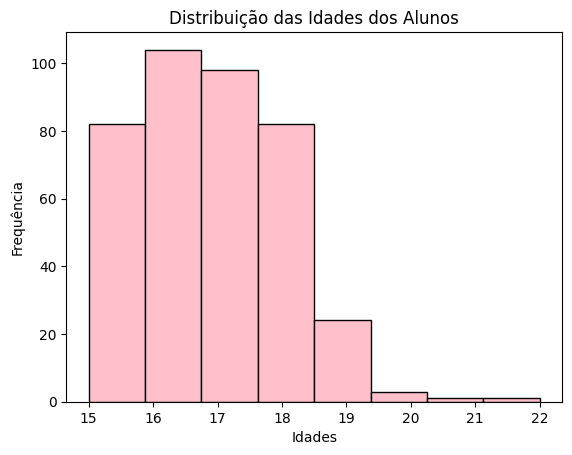

In [176]:
# Coluna de idade
idade = df["age"]

# Teste de normalidade
alpha = 0.05
w, p = stats.shapiro(idade)

# Resultado
if w == 1:
    print("A distribuição das idades é aproximadamente normal.")
else:
    if p > alpha:
        print("A distribuição das idades é aproximadamente normal.")
    else:
        print("A distribuição das idades não é normal.")


plt.hist(idade, bins=8, color='pink', edgecolor='black')
plt.xlabel('Idades')
plt.ylabel('Frequência')
plt.title('Distribuição das Idades dos Alunos')
plt.show()

> Idade, Notas Finais e Faltas não possuem uma distribuição normal. Isso não significa necessariamente algo ruim em todos os casos. Depende do contexto e da análise que está sendo realizada.





# **👉🏻 Intervalo de Confiança**

### 4. Qual é a proporção de alunos que desejam cursar o ensino superior (higher) com um intervalo de confiança de 90%?

In [168]:
import numpy as np
from scipy import stats
import math

# Filtrar os dados relevantes do DataFrame
higher = df['higher']

# Tamanho da amostra
n = len(higher)

# Nível de confiança desejado (ex: 90%)
confidence_level = 0.90

# Calcular o número de alunos que desejam cursar o ensino superior
num_higher = np.sum(higher == 'yes')

# Calcular a proporção de alunos que desejam cursar o ensino superior
prop_higher = num_higher / n

# Calcular o erro padrão
se = math.sqrt((prop_higher * (1 - prop_higher)) / n)

# Calcular o valor crítico (Z-score) usando a distribuição normal padrão
z = stats.norm.ppf((1 + confidence_level) / 2)

# Calcular o intervalo de confiança
ci_lower = prop_higher - z * se
ci_upper = prop_higher + z * se


print("Proporção de alunos que desejam cursar o ensino superior:", prop_higher)
print("Intervalo de confiança:", ci_lower, "-", ci_upper)


Proporção de alunos que desejam cursar o ensino superior: 0.9493670886075949
Intervalo de confiança: 0.9312218683185303 - 0.9675123088966595



> A proporção de alunos que desejam cursar o ensino superior é de aproximadamente 0.9494, o que significa que cerca de 94.94% dos alunos da amostra expressaram o desejo de cursar o ensino superior.


> O intervalo de confiança de 90% para essa proporção é de 0.9312 a 0.9675. Isso indica que, com 90% de confiança, a verdadeira proporção de alunos que desejam cursar o ensino superior na população em geral está estimada para estar entre 0.9312 e 0.9675.

> Esses resultados sugerem que uma alta proporção de alunos na amostra expressaram o desejo de cursar o ensino superior, e com um intervalo de confiança de 90%, podemos ter um bom grau de confiança na estimativa da proporção na população geral.





### 5. Qual é a proporção de alunos que consomem álcool no final de semana (Walc) com um intervalo de confiança de 90%?

In [134]:
import numpy as np
from scipy import stats
import math

# Filtrar os dados relevantes do DataFrame
walc = df['Walc']

# Tamanho da amostra
n = len(walc)

# Nível de confiança desejado (ex: 90%)
confidence_level = 0.90

# Calcular o número de alunos que consomem álcool no final de semana
num_walc = np.sum(walc > 1)  # Considerando valores maiores que 1 indicando consumo de álcool

# Calcular a proporção de alunos que consomem álcool no final de semana
prop_walc = num_walc / n

# Calcular o erro padrão
se = math.sqrt((prop_walc * (1 - prop_walc)) / n)

# Calcular o valor crítico (Z-score) usando a distribuição normal padrão
z = stats.norm.ppf((1 + confidence_level) / 2)

# Calcular o intervalo de confiança
ci_lower = prop_walc - z * se
ci_upper = prop_walc + z * se

print("Proporção de alunos que consomem álcool no final de semana:", prop_walc)
print("Intervalo de confiança:", ci_lower, "-", ci_upper)


Proporção de alunos que consomem álcool no final de semana: 0.6177215189873417
Intervalo de confiança: 0.5775040254992017 - 0.6579390124754818


> A proporção de alunos que consomem álcool no final de semana é de aproximadamente 0.6177, o que significa que cerca de 61.77% dos alunos da amostra relataram consumir álcool no final de semana.

> Além disso, o intervalo de confiança de 90% para essa proporção é de 0.5775 a 0.6579. Isso significa que, com 90% de confiança, podemos estimar que a proporção real de alunos que consomem álcool no final de semana na população em geral está entre 0.5775 e 0.6579.

> Esses resultados indicam que uma proporção significativa de alunos na amostra relatou consumir álcool no final de semana.


# **👉🏻 Análise de Regressão**



> O objetivo principal da análise de regressão é modelar e estimar a relação funcional entre as variáveis, bem como fazer previsões ou inferências com base nesse modelo.



### 6. O tempo de viagem de casa para a escola (traveltime) afeta a frequência de faltas escolares (absences) dos alunos?

In [146]:
import pandas as pd
import statsmodels.api as sm


# Converter a coluna "traveltime" para tipo numérico
traveltime = pd.to_numeric(df['traveltime'], errors='coerce')
absences= df['absences'].astype(int)

# Remover linhas com valores ausentes na coluna "traveltime" ou "absences"
data = df.dropna(subset=['traveltime', 'absences'])

# Definir as variáveis independentes e dependentes
X = traveltime
y = absences

# Adicionar uma constante aos dados independentes
X = sm.add_constant(X)

# Ajustar o modelo de regressão linear
model = sm.OLS(y, X)
results = model.fit()

# Imprimir os resultados da regressão
print(results.summary())


                            OLS Regression Results                            
Dep. Variable:               absences   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                   0.06585
Date:                Fri, 30 Jun 2023   Prob (F-statistic):              0.798
Time:                        21:23:08   Log-Likelihood:                -1381.5
No. Observations:                 395   AIC:                             2767.
Df Residuals:                     393   BIC:                             2775.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.9239      0.930      6.370      0.0

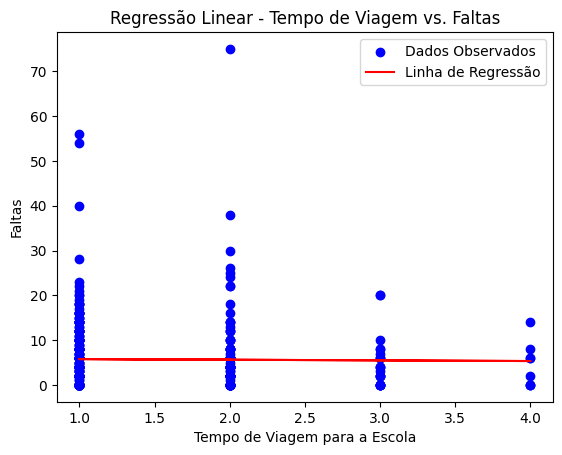

In [147]:
import matplotlib.pyplot as plt

# Criar o gráfico de dispersão
plt.scatter(X['traveltime'], y, color='blue', label='Dados Observados')

# Adicionar a linha de regressão
plt.plot(X['traveltime'], results.fittedvalues, color='red', label='Linha de Regressão')

# Definir rótulos e título do gráfico
plt.xlabel('Tempo de Viagem para a Escola')
plt.ylabel('Faltas')
plt.title('Regressão Linear - Tempo de Viagem vs. Faltas')

# Adicionar legenda
plt.legend()

# Exibir o gráfico
plt.show()

> Não há evidências estatísticas suficientes para afirmar que o tempo de viagem de casa para a escola tem uma relação significativa com a frequência de faltas escolares dos alunos.




# **👉🏻 Análise de Variância**



> O objetivo da ANOVA é determinar se existe uma diferença estatisticamente significativa entre as médias dos grupos e identificar quais grupos diferem entre si.


### 7. Existe diferença nas notas finais (G3) entre alunos de diferentes escolas (school)?





In [172]:
# Separar as notas finais (G3) por escola (school)
school_gp = df[df['school'] == 'GP']['G3']
school_ms = df[df['school'] == 'MS']['G3']

# Realizar a análise de variância (ANOVA)
f_value, p_value = stats.f_oneway(school_gp, school_ms)

# Imprimir o resultado
print("Estatística F:", f_value)
print("Valor p:", p_value)

Estatística F: 0.7980416422082741
Valor p: 0.3722262371311368




> Nesse caso, o valor p encontrado (0.3722262371311368) é maior que o nível de significância usual de 0.05. Isso significa que não há evidências estatísticas suficientes para afirmar que existe uma diferença significativa nas notas finais entre os alunos das diferentes escolas.


### 8. Existe diferença faltas (absences) entre alunos de diferentes escolas (school)?



In [173]:
# Separar as notas finais (G3) por escola (school)
absences_gp = df[df['school'] == 'GP']['absences']
absences_ms = df[df['school'] == 'MS']['absences']

# Realizar a análise de variância (ANOVA)
f_value, p_value = stats.f_oneway(absences_gp, absences_ms)

# Imprimir o resultado
print("Estatística F:", f_value)
print("Valor p:", p_value)

Estatística F: 3.1009669740081782
Valor p: 0.07902347435910269



> A estatística F é uma medida da variação entre os grupos (no caso, as escolas) em relação à variação dentro dos grupos. Quanto maior o valor da estatística F, maior a diferença entre as médias dos grupos em relação à variabilidade dentro dos grupos.

> O valor p, por sua vez, é a probabilidade de obter uma estatística F igual ou mais extrema do que a observada, assumindo que a hipótese nula seja verdadeira. No contexto da análise de variância, a hipótese nula é que *não há diferença significativa entre as médias dos grupos*.

 # **👉🏻 Z-score**



> É uma medida estatística que nos ajuda a avaliar o quão distante um determinado valor está da média em termos de desvios padrão.



### 9. Qual é o z-score da quantidade de faltas escolares?




In [171]:
# Calcular o z-score das faltas escolares
z_scores = np.abs((df['absences'] - df['absences'].mean()) / df['absences'].std())

# Você pode acessar o z-score de um valor específico
indice_valor_especifico = 0  # Índice do valor específico que você deseja calcular o z-score
z_score_valor_especifico = z_scores[indice_valor_especifico]

# Imprimir o z-score do valor específico
print(f"O z-score do valor específico é: {z_score_valor_especifico}")


O z-score do valor específico é: 0.03637832807313696




> O valor do z-score específico calculado como 0.03637832807313696 indica que o valor em questão, na variável de faltas escolares, está aproximadamente 0.036 desvios padrão acima da média da distribuição dos dados de faltas escolares.

> Nesse caso específico, como o z-score é próximo de zero (0.03637832807313696), significa que o valor em questão está muito próximo da média da distribuição dos dados de faltas escolares. Portanto, não é considerado um valor atípico (outlier) em relação à distribuição.



### 10. Qual é o z-score do estado de saúde dos estudantes?






In [170]:
# Calcular o z-score das faltas escolares
z_scores = np.abs((df['health'] - df['health'].mean()) / df['health'].std())

# Você pode acessar o z-score de um valor específico
indice_valor_especifico = 0  # Índice do valor específico que você deseja calcular o z-score
z_score_valor_especifico = z_scores[indice_valor_especifico]

# Imprimir o z-score do valor específico
print(f"O z-score do valor específico é: {z_score_valor_especifico}")

O z-score do valor específico é: 0.39878373541518675




> No caso específico mencionado, um z-score de 0.39878373541518675 indica que o estado de saúde dos estudantes está cerca de 0.40 desvios padrão acima da média da distribuição de estado de saúde.

